In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("\nTipos de datos:")
print(df.dtypes)

Filas: 7043, Columnas: 21

Tipos de datos:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [2]:
# Diagnóstico de nulos
print("=== Nulos por columna ===")
print(df.isnull().sum())

print("\n=== TotalCharges — valores únicos problemáticos ===")
# Convertimos forzado y vemos qué explota
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Nulos en TotalCharges después de conversión: {df['TotalCharges'].isnull().sum()}")

print("\n=== Distribución de Churn (variable objetivo) ===")
print(df['Churn'].value_counts())
print(f"\nTasa de churn: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

=== Nulos por columna ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== TotalCharges — valores únicos problemáticos ===
Nulos en TotalCharges después de conversión: 11

=== Distribución de Churn (variable objetivo) ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Tasa de churn: 26.5%


In [3]:
# Ver las filas con TotalCharges nulo
print("=== Clientes con TotalCharges nulo ===")
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

print("\n=== Estadísticas columnas numéricas ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

=== Clientes con TotalCharges nulo ===
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

=== Estadísticas columnas numéricas ===
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000

In [4]:
# Imputamos con criterio de negocio — tenure 0 = sin facturación
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verificamos
print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isnull().sum()}")

print("\n=== Estadísticas columnas numéricas ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

Nulos restantes en TotalCharges: 0

=== Estadísticas columnas numéricas ===
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [5]:
# Churn por método de pago
print("=== Tasa de churn por método de pago ===")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack())

print("\n=== Tasa de churn por tipo de contrato ===")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())

=== Tasa de churn por método de pago ===
Churn                            No       Yes
PaymentMethod                                
Bank transfer (automatic)  0.832902  0.167098
Credit card (automatic)    0.847569  0.152431
Electronic check           0.547146  0.452854
Mailed check               0.808933  0.191067

=== Tasa de churn por tipo de contrato ===
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


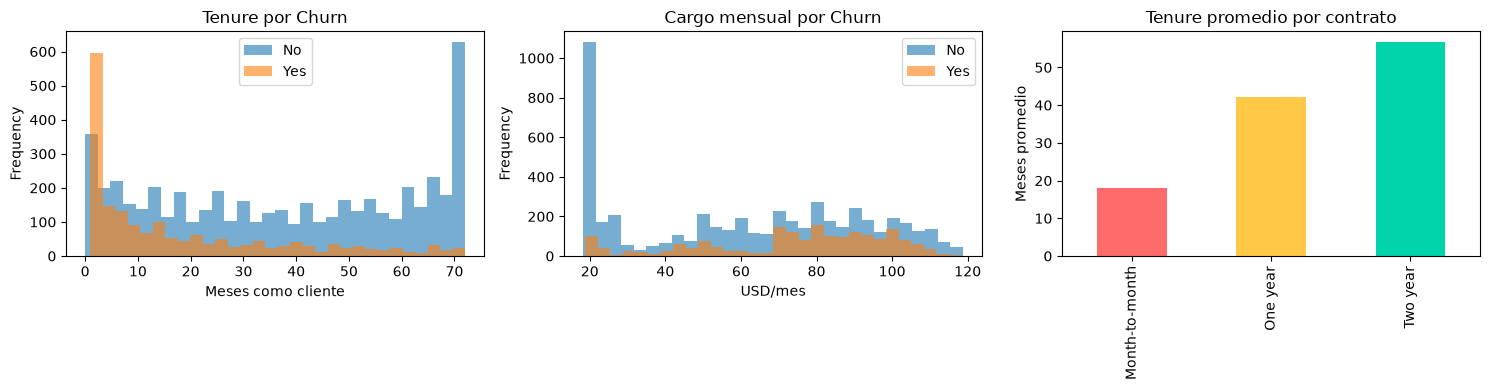

=== Tenure promedio por grupo ===
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64

=== MonthlyCharges promedio por grupo ===
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [6]:
import matplotlib.pyplot as plt

# Tenure vs Churn — el comportamiento en el tiempo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1 — Distribución de tenure por Churn
df.groupby('Churn')['tenure'].plot(
    kind='hist', 
    bins=30, 
    alpha=0.6, 
    ax=axes[0],
    legend=True
)
axes[0].set_title('Tenure por Churn')
axes[0].set_xlabel('Meses como cliente')

# Gráfico 2 — MonthlyCharges vs Churn
df.groupby('Churn')['MonthlyCharges'].plot(
    kind='hist',
    bins=30,
    alpha=0.6,
    ax=axes[1],
    legend=True
)
axes[1].set_title('Cargo mensual por Churn')
axes[1].set_xlabel('USD/mes')

# Gráfico 3 — Tenure promedio por contrato
df.groupby('Contract')['tenure'].mean().plot(
    kind='bar',
    ax=axes[2],
    color=['#ff6b6b', '#ffc947', '#00d4aa']
)
axes[2].set_title('Tenure promedio por contrato')
axes[2].set_xlabel('')
axes[2].set_ylabel('Meses promedio')

plt.tight_layout()
plt.show()

# Números detrás de los gráficos
print("=== Tenure promedio por grupo ===")
print(df.groupby('Churn')['tenure'].mean().round(1))

print("\n=== MonthlyCharges promedio por grupo ===")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

In [7]:
# ===========================================
# HALLAZGOS EDA — Telco Customer Churn
# Fecha: 2026-06-12
# ===========================================
# 1. Dataset: 7,043 clientes, 21 columnas, churn 26.5%
# 2. TotalCharges: 11 nulos por tenure=0, imputados con 0
# 3. Predictores clave identificados:
#    - Contract: month-to-month = 42.7% churn vs 2.8% two-year
#    - PaymentMethod: electronic check = 45.3% churn
#    - Tenure: clientes que se van promedian 18 meses vs 37.6
#    - MonthlyCharges: clientes que se van pagan $74 vs $61
# 4. Segmento dormido: ~$20/mes, sin internet, churn casi cero
# 5. Paradoja premium: Fiber optic = mayor costo = mayor churn
# ===========================================

In [8]:
import numpy as np

# Array de cargos mensuales — simulando 5 clientes
charges = np.array([20.5, 70.3, 45.8, 99.1, 55.0])

print(f"Tipo: {type(charges)}")
print(f"Dtype: {charges.dtype}")
print(f"Shape: {charges.shape}")
print(f"Datos: {charges}")

Tipo: <class 'numpy.ndarray'>
Dtype: float64
Shape: (5,)
Datos: [20.5 70.3 45.8 99.1 55. ]


In [9]:
import time

# Datos grandes — 1 millón de cargos simulados
big_charges = np.random.uniform(20, 120, 1_000_000)

# Método 1 — loop Python
start = time.time()
result_loop = []
for c in big_charges:
    result_loop.append(c * 1.10)
loop_time = time.time() - start

# Método 2 — vectorización NumPy
start = time.time()
result_numpy = big_charges * 1.10
numpy_time = time.time() - start

print(f"Loop Python:      {loop_time:.4f} segundos")
print(f"NumPy vectorizado: {numpy_time:.4f} segundos")
print(f"NumPy es {loop_time/numpy_time:.0f}x más rápido")

Loop Python:      0.1063 segundos
NumPy vectorizado: 0.0056 segundos
NumPy es 19x más rápido


In [10]:
# Usamos los MonthlyCharges reales del dataset
charges = df['MonthlyCharges'].values  # .values convierte columna Pandas a array NumPy

print(f"Tipo: {type(charges)}")
print(f"Shape: {charges.shape}")
print(f"\n--- Estadísticas vectorizadas ---")
print(f"Promedio:    ${np.mean(charges):.2f}")
print(f"Mediana:     ${np.median(charges):.2f}")
print(f"Desv. std:   ${np.std(charges):.2f}")
print(f"Mínimo:      ${np.min(charges):.2f}")
print(f"Máximo:      ${np.max(charges):.2f}")

print(f"\n--- Operaciones de negocio ---")
# ¿Cuántos clientes pagan más de $70?
premium = np.sum(charges > 70)
print(f"Clientes premium (>$70): {premium} ({premium/len(charges):.1%})")

# ¿Cuál sería el ingreso total si subimos 5% los cargos?
ingreso_actual = np.sum(charges)
ingreso_nuevo = np.sum(charges * 1.05)
print(f"Ingreso actual/mes:  ${ingreso_actual:,.2f}")
print(f"Ingreso con +5%/mes: ${ingreso_nuevo:,.2f}")
print(f"Diferencia:          ${ingreso_nuevo - ingreso_actual:,.2f}")


Tipo: <class 'numpy.ndarray'>
Shape: (7043,)

--- Estadísticas vectorizadas ---
Promedio:    $64.76
Mediana:     $70.35
Desv. std:   $30.09
Mínimo:      $18.25
Máximo:      $118.75

--- Operaciones de negocio ---
Clientes premium (>$70): 3583 (50.9%)
Ingreso actual/mes:  $456,116.60
Ingreso con +5%/mes: $478,922.43
Diferencia:          $22,805.83


In [11]:
# Broadcasting — operar arrays de distinto tamaño
# Escenario: descuento por segmento de tenure

tenure = df['tenure'].values
charges = df['MonthlyCharges'].values

# Definimos descuentos por antigüedad
# < 12 meses → 0% descuento
# 12-24 meses → 5% descuento  
# > 24 meses → 10% descuento
descuentos = np.where(tenure < 12, 0.0,
             np.where(tenure <= 24, 0.05, 0.10))

charges_con_descuento = charges * (1 - descuentos)

print("=== Impacto del programa de descuentos por fidelidad ===")
print(f"Clientes nuevos (<12m):     {np.sum(tenure < 12):,} clientes — sin descuento")
print(f"Clientes medios (12-24m):   {np.sum((tenure >= 12) & (tenure <= 24)):,} clientes — 5% descuento")
print(f"Clientes fieles (>24m):     {np.sum(tenure > 24):,} clientes — 10% descuento")
print(f"\nIngreso actual/mes:         ${np.sum(charges):,.2f}")
print(f"Ingreso con descuentos/mes: ${np.sum(charges_con_descuento):,.2f}")
print(f"Costo del programa:         ${np.sum(charges) - np.sum(charges_con_descuento):,.2f}")

=== Impacto del programa de descuentos por fidelidad ===
Clientes nuevos (<12m):     2,069 clientes — sin descuento
Clientes medios (12-24m):   1,141 clientes — 5% descuento
Clientes fieles (>24m):     3,833 clientes — 10% descuento

Ingreso actual/mes:         $456,116.60
Ingreso con descuentos/mes: $425,576.92
Costo del programa:         $30,539.68


In [12]:
# Una máscara booleana es un array de True/False
# que usas para filtrar otro array

charges = df['MonthlyCharges'].values
tenure = df['tenure'].values
churn = df['Churn'].values

# Máscara — clientes en riesgo alto
# Definición: nuevos (<12m) + premium (>$70) + mes a mes
contrato = df['Contract'].values
metodo_pago = df['PaymentMethod'].values

mascara_riesgo_alto = (
    (tenure < 12) &
    (charges > 70) &
    (contrato == 'Month-to-month')
)

print("=== Segmento de riesgo alto ===")
print(f"Total clientes:          {len(charges):,}")
print(f"En riesgo alto:          {np.sum(mascara_riesgo_alto):,}")
print(f"Porcentaje:              {np.mean(mascara_riesgo_alto):.1%}")

# Aplicamos la máscara para ver SUS números
charges_riesgo = charges[mascara_riesgo_alto]
churn_riesgo = churn[mascara_riesgo_alto]

print(f"\nCargo promedio segmento: ${np.mean(charges_riesgo):.2f}")
print(f"Churn real en segmento:  {np.mean(churn_riesgo == 'Yes'):.1%}")
print(f"Ingreso mensual en riesgo: ${np.sum(charges_riesgo):,.2f}")

=== Segmento de riesgo alto ===
Total clientes:          7,043
En riesgo alto:          814
Porcentaje:              11.6%

Cargo promedio segmento: $82.82
Churn real en segmento:  69.5%
Ingreso mensual en riesgo: $67,418.90


In [13]:
# Vamos a construir un score de riesgo simple
# combinando múltiples variables — esto es el embrión del modelo del Mes 3

# Extraemos variables numéricas
tenure = df['tenure'].values
charges = df['MonthlyCharges'].values

# Normalizamos entre 0 y 1 — técnica estándar en ML
# Min-Max scaling vectorizado
def minmax_scale(array):
    return (array - np.min(array)) / (np.max(array) - np.min(array))

tenure_norm = minmax_scale(tenure)
charges_norm = minmax_scale(charges)

# Score de riesgo — invertimos tenure (menos tenure = más riesgo)
# y sumamos charges (más cargo = más riesgo si es nuevo)
PESO_TENURE = 0.6   # tenure pesa más — es el predictor más fuerte
PESO_CHARGES = 0.4  # charges pesa menos

risk_score = (1 - tenure_norm) * PESO_TENURE + charges_norm * PESO_CHARGES

print("=== Score de riesgo de churn (0=bajo, 1=alto) ===")
print(f"Score promedio global:        {np.mean(risk_score):.3f}")
print(f"Score promedio — churn Yes:   {np.mean(risk_score[df['Churn'].values == 'Yes']):.3f}")
print(f"Score promedio — churn No:    {np.mean(risk_score[df['Churn'].values == 'No']):.3f}")

print("\n=== Distribución por nivel de riesgo ===")
alto   = np.sum(risk_score > 0.6)
medio  = np.sum((risk_score >= 0.3) & (risk_score <= 0.6))
bajo   = np.sum(risk_score < 0.3)

print(f"Riesgo alto  (>0.6): {alto:,} clientes ({alto/len(risk_score):.1%})")
print(f"Riesgo medio (0.3-0.6): {medio:,} clientes ({medio/len(risk_score):.1%})")
print(f"Riesgo bajo  (<0.3): {bajo:,} clientes ({bajo/len(risk_score):.1%})")

print("\n=== Ingreso en riesgo por nivel ===")
print(f"Riesgo alto:  ${np.sum(charges[risk_score > 0.6]):,.2f}/mes")
print(f"Riesgo medio: ${np.sum(charges[(risk_score >= 0.3) & (risk_score <= 0.6)]):,.2f}/mes")
print(f"Riesgo bajo:  ${np.sum(charges[risk_score < 0.3]):,.2f}/mes")

=== Score de riesgo de churn (0=bajo, 1=alto) ===
Score promedio global:        0.515
Score promedio — churn Yes:   0.674
Score promedio — churn No:    0.458

=== Distribución por nivel de riesgo ===
Riesgo alto  (>0.6): 2,647 clientes (37.6%)
Riesgo medio (0.3-0.6): 3,196 clientes (45.4%)
Riesgo bajo  (<0.3): 1,200 clientes (17.0%)

=== Ingreso en riesgo por nivel ===
Riesgo alto:  $196,292.20/mes
Riesgo medio: $207,202.80/mes
Riesgo bajo:  $52,621.60/mes


In [14]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Filtrar clientes con InternetService = No
cond_internet = df["InternetService"] == "No"

# Filtrar clientes con StreamingTV o StreamingMovies activos
cond_streaming = (df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes")

# Aplicar ambas condiciones
clientes_filtrados = df[cond_internet & cond_streaming]

# Contar resultados
cantidad_clientes = clientes_filtrados.shape[0]
print("Número de clientes:", cantidad_clientes)

print("Número de internet:", cond_internet)
print("Número de streaming:", cond_streaming)


Número de clientes: 0
Número de internet: 0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: InternetService, Length: 7043, dtype: bool
Número de streaming: 0       False
1       False
2       False
3       False
4       False
        ...  
7038     True
7039     True
7040    False
7041    False
7042     True
Length: 7043, dtype: bool


In [15]:
# Resumen cruzado de InternetService vs StreamingTV y StreamingMovies
tabla_tv = pd.crosstab(df["InternetService"], df["StreamingTV"])
tabla_movies = pd.crosstab(df["InternetService"], df["StreamingMovies"])

print("Distribución StreamingTV:")
print(tabla_tv)

print("\nDistribución StreamingMovies:")
print(tabla_movies)

# Resumen general por tipo de servicio
resumen_servicios = df.groupby("InternetService")[["StreamingTV", "StreamingMovies", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]].describe()

print(resumen_servicios)

Distribución StreamingTV:
StreamingTV        No  No internet service   Yes
InternetService                                 
DSL              1464                    0   957
Fiber optic      1346                    0  1750
No                  0                 1526     0

Distribución StreamingMovies:
StreamingMovies    No  No internet service   Yes
InternetService                                 
DSL              1440                    0   981
Fiber optic      1345                    0  1751
No                  0                 1526     0
                StreamingTV                                   StreamingMovies  \
                      count unique                  top  freq           count   
InternetService                                                                 
DSL                    2421      2                   No  1464            2421   
Fiber optic            3096      2                  Yes  1750            3096   
No                     1526      1  No internet 

In [16]:
# import pandas as pd

# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Lista de servicios a analizar
servicios = ["StreamingTV", "StreamingMovies", "OnlineSecurity", 
             "OnlineBackup", "DeviceProtection", "TechSupport"]

# Construir tabla consolidada
tabla_consolidada = pd.DataFrame()

for servicio in servicios:
    conteo = pd.crosstab(df["InternetService"], df[servicio])
    # Tomamos solo la columna "Yes" si existe
    if "Yes" in conteo.columns:
        tabla_consolidada[servicio] = conteo["Yes"]

# Agregar total de clientes por InternetService
tabla_consolidada["Total clientes"] = df["InternetService"].value_counts()

print(tabla_consolidada)


                 StreamingTV  StreamingMovies  OnlineSecurity  OnlineBackup  \
InternetService                                                               
DSL                      957              981            1180          1086   
Fiber optic             1750             1751             839          1343   
No                         0                0               0             0   

                 DeviceProtection  TechSupport  Total clientes  
InternetService                                                 
DSL                          1065         1178            2421  
Fiber optic                  1357          866            3096  
No                              0            0            1526  


In [17]:
import numpy as np
import pandas as pd

# Recargamos por si acaso
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Función para detectar outliers con IQR
def detectar_outliers_iqr(serie, nombre):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    print(f"=== Outliers en {nombre} ===")
    print(f"Q1: ${Q1:.2f} | Q3: ${Q3:.2f} | IQR: ${IQR:.2f}")
    print(f"Límite inferior: ${limite_inferior:.2f}")
    print(f"Límite superior: ${limite_superior:.2f}")
    print(f"Outliers encontrados: {len(outliers)} ({len(outliers)/len(serie):.1%})")
    return outliers

outliers_charges = detectar_outliers_iqr(df['MonthlyCharges'], 'MonthlyCharges')
outliers_tenure = detectar_outliers_iqr(df['tenure'], 'tenure')

=== Outliers en MonthlyCharges ===
Q1: $35.50 | Q3: $89.85 | IQR: $54.35
Límite inferior: $-46.02
Límite superior: $171.38
Outliers encontrados: 0 (0.0%)
=== Outliers en tenure ===
Q1: $9.00 | Q3: $55.00 | IQR: $46.00
Límite inferior: $-60.00
Límite superior: $124.00
Outliers encontrados: 0 (0.0%)


In [18]:
# Un cliente que paga $90/mes es normal en Fiber optic
# El mismo cliente en DSL es una anomalía
# Eso es lo que vamos a detectar ahora

print("=== Análisis de anomalías por segmento de Internet ===\n")

for servicio in df['InternetService'].unique():
    segmento = df[df['InternetService'] == servicio]['MonthlyCharges']
    
    Q1 = segmento.quantile(0.25)
    Q3 = segmento.quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    limite_inf = max(0, Q1 - 1.5 * IQR)  # nunca negativo en negocio
    
    outliers = df[
        (df['InternetService'] == servicio) &
        ((df['MonthlyCharges'] > limite_sup) | 
         (df['MonthlyCharges'] < limite_inf))
    ]
    
    print(f"Segmento: {servicio}")
    print(f"  Rango normal: ${limite_inf:.2f} — ${limite_sup:.2f}")
    print(f"  Outliers:     {len(outliers)} clientes ({len(outliers)/len(segmento):.1%})")
    if len(outliers) > 0:
        print(f"  Churn en outliers: {(outliers['Churn'] == 'Yes').mean():.1%}")
    print()

=== Análisis de anomalías por segmento de Internet ===

Segmento: DSL
  Rango normal: $10.65 — $105.45
  Outliers:     0 clientes (0.0%)

Segmento: Fiber optic
  Rango normal: $49.65 — $132.05
  Outliers:     0 clientes (0.0%)

Segmento: No
  Rango normal: $17.90 — $22.70
  Outliers:     342 clientes (22.4%)
  Churn en outliers: 2.9%



In [19]:
# ¿Quiénes son los 342 outliers sin internet?
sin_internet = df[df['InternetService'] == 'No']

Q1 = sin_internet['MonthlyCharges'].quantile(0.25)
Q3 = sin_internet['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = max(0, Q1 - 1.5 * IQR)
limite_sup = Q3 + 1.5 * IQR

outliers_sin_internet = sin_internet[
    (sin_internet['MonthlyCharges'] > limite_sup) |
    (sin_internet['MonthlyCharges'] < limite_inf)
]

print(f"Rango normal Sin Internet: ${limite_inf:.2f} — ${limite_sup:.2f}")
print(f"\n=== Distribución de cargos de los 342 outliers ===")
print(outliers_sin_internet['MonthlyCharges'].describe())

print(f"\n=== ¿Qué servicios tienen estos 342 clientes? ===")
columnas_servicio = ['PhoneService', 'MultipleLines', 'Churn']
print(outliers_sin_internet[columnas_servicio].value_counts())

print(f"\n=== Sus cargos exactos — los más altos ===")
print(outliers_sin_internet[['customerID', 'MonthlyCharges', 
    'PhoneService', 'MultipleLines', 'Contract', 
    'PaymentMethod', 'Churn']]
    .sort_values('MonthlyCharges', ascending=False)
    .head(20))

Rango normal Sin Internet: $17.90 — $22.70

=== Distribución de cargos de los 342 outliers ===
count    342.000000
mean      24.970614
std        0.699764
min       22.950000
25%       24.462500
50%       25.000000
75%       25.450000
max       26.900000
Name: MonthlyCharges, dtype: float64

=== ¿Qué servicios tienen estos 342 clientes? ===
PhoneService  MultipleLines  Churn
Yes           Yes            No       332
                             Yes       10
Name: count, dtype: int64

=== Sus cargos exactos — los más altos ===
      customerID  MonthlyCharges PhoneService MultipleLines        Contract  \
2552  3547-LQRIK           26.90          Yes           Yes        One year   
2331  2809-ILCYT           26.80          Yes           Yes        One year   
5596  5982-XMDEX           26.50          Yes           Yes        Two year   
5193  7096-ZNBZI           26.45          Yes           Yes        Two year   
4650  6509-TSGWN           26.45          Yes           Yes  Month-to-mon

In [20]:
# Perfil anómalo: cliente nuevo + sin contrato + 
# paga mucho + método de pago sospechoso
print("=== Perfiles de comportamiento anómalo ===\n")

# Perfil 1 — Cliente fantasma
# Nuevo + sin compromiso + pago no automático
perfil_1 = df[
    (df['tenure'] <= 3) &
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75))
]

print(f"Perfil 1 — Cliente fantasma (nuevo+sin contrato+check+premium):")
print(f"  Clientes:          {len(perfil_1)}")
print(f"  Churn:             {(perfil_1['Churn'] == 'Yes').mean():.1%}")
print(f"  Cargo promedio:    ${perfil_1['MonthlyCharges'].mean():.2f}")
print(f"  Ingreso en riesgo: ${perfil_1['MonthlyCharges'].sum():,.2f}/mes")

# Perfil 2 — Cliente invisible
# Lleva tiempo pero nunca acumuló TotalCharges significativo
perfil_2 = df[
    (df['tenure'] > 24) &
    (df['TotalCharges'] < df['TotalCharges'].quantile(0.25)) &
    (df['MonthlyCharges'] > 50)
]

print(f"\nPerfil 2 — Cliente invisible (antiguo+bajo total+cargo medio-alto):")
print(f"  Clientes:          {len(perfil_2)}")
print(f"  Churn:             {(perfil_2['Churn'] == 'Yes').mean():.1%}")
print(f"  Tenure promedio:   {perfil_2['tenure'].mean():.1f} meses")
print(f"  TotalCharges prom: ${perfil_2['TotalCharges'].mean():,.2f}")

# Perfil 3 — El que no encaja en ningún segmento
# Fiber optic pero paga como DSL
perfil_3 = df[
    (df['InternetService'] == 'Fiber optic') &
    (df['MonthlyCharges'] < df[df['InternetService'] == 'DSL']['MonthlyCharges'].quantile(0.75))
]

print(f"\nPerfil 3 — Fiber optic que paga como DSL:")
print(f"  Clientes:          {len(perfil_3)}")
print(f"  Churn:             {(perfil_3['Churn'] == 'Yes').mean():.1%}")
print(f"  Cargo promedio:    ${perfil_3['MonthlyCharges'].mean():.2f}")

=== Perfiles de comportamiento anómalo ===

Perfil 1 — Cliente fantasma (nuevo+sin contrato+check+premium):
  Clientes:          59
  Churn:             78.0%
  Cargo promedio:    $95.09
  Ingreso en riesgo: $5,610.35/mes

Perfil 2 — Cliente invisible (antiguo+bajo total+cargo medio-alto):
  Clientes:          0
  Churn:             nan%
  Tenure promedio:   nan meses
  TotalCharges prom: $nan

Perfil 3 — Fiber optic que paga como DSL:
  Clientes:          90
  Churn:             62.2%
  Cargo promedio:    $69.38


In [21]:
print("=== Perfil 3 — Fiber optic que paga como DSL ===\n")

# Referencia DSL
dsl_q75 = df[df['InternetService'] == 'DSL']['MonthlyCharges'].quantile(0.75)
print(f"Referencia DSL Q75: ${dsl_q75:.2f}")

perfil_3 = df[
    (df['InternetService'] == 'Fiber optic') &
    (df['MonthlyCharges'] < dsl_q75)
]

print(f"\n=== Sus servicios activos ===")
servicios = ['StreamingTV', 'StreamingMovies', 'OnlineSecurity', 
             'OnlineBackup', 'DeviceProtection', 'TechSupport']
for s in servicios:
    activos = (perfil_3[s] == 'Yes').sum()
    print(f"{s}: {activos} de {len(perfil_3)} ({activos/len(perfil_3):.0%})")

print(f"\n=== Contrato y método de pago ===")
print(perfil_3['Contract'].value_counts())
print()
print(perfil_3['PaymentMethod'].value_counts())

print(f"\n=== Tenure ===")
print(perfil_3['tenure'].describe())

=== Perfil 3 — Fiber optic que paga como DSL ===

Referencia DSL Q75: $69.90

=== Sus servicios activos ===
StreamingTV: 0 de 90 (0%)
StreamingMovies: 0 de 90 (0%)
OnlineSecurity: 0 de 90 (0%)
OnlineBackup: 0 de 90 (0%)
DeviceProtection: 0 de 90 (0%)
TechSupport: 0 de 90 (0%)

=== Contrato y método de pago ===
Contract
Month-to-month    89
Two year           1
Name: count, dtype: int64

PaymentMethod
Electronic check             60
Bank transfer (automatic)    13
Mailed check                 11
Credit card (automatic)       6
Name: count, dtype: int64

=== Tenure ===
count    90.000000
mean      9.033333
std      12.781175
min       1.000000
25%       1.000000
50%       3.000000
75%       8.750000
max      55.000000
Name: tenure, dtype: float64


In [22]:
def evaluar_riesgo_cliente(cliente: pd.Series) -> dict:
    """
    Batería de reglas de negocio basadas en EDA.
    Retorna perfil de riesgo con alertas explicables.
    """
    alertas = []
    nivel_riesgo = 0

    # Regla 1 — Cliente fantasma
    if (cliente['tenure'] <= 3 and
        cliente['Contract'] == 'Month-to-month' and
        cliente['PaymentMethod'] == 'Electronic check' and
        cliente['MonthlyCharges'] > 89.85):  # Q3 del dataset
        alertas.append("ALTA: Cliente fantasma — nuevo+sin contrato+check+premium")
        nivel_riesgo += 3

    # Regla 2 — Bandwidth squatter
    servicios = ['StreamingTV', 'StreamingMovies', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport']
    servicios_activos = sum(cliente[s] == 'Yes' for s in servicios)

    if (cliente['InternetService'] == 'Fiber optic' and
        cliente['MonthlyCharges'] < 69.90 and
        servicios_activos == 0 and
        cliente['tenure'] < 6):
        alertas.append("ALTA: Bandwidth squatter — Fiber optic sin servicios+precio DSL")
        nivel_riesgo += 3

    # Regla 3 — Método de pago sospechoso + nuevo
    if (cliente['PaymentMethod'] == 'Electronic check' and
        cliente['tenure'] < 12):
        alertas.append("MEDIA: Nuevo cliente con electronic check")
        nivel_riesgo += 1

    # Regla 4 — Contrato débil + premium
    if (cliente['Contract'] == 'Month-to-month' and
        cliente['MonthlyCharges'] > 89.85):
        alertas.append("MEDIA: Cliente premium sin compromiso contractual")
        nivel_riesgo += 1

    # Regla 5 — Combinación letal (lo que validamos el viernes)
    if (cliente['tenure'] < 12 and
        cliente['Contract'] == 'Month-to-month' and
        cliente['InternetService'] == 'Fiber optic'):
        alertas.append("ALTA: Combinación letal — nuevo+mes a mes+Fiber optic")
        nivel_riesgo += 2

    # Clasificación final
    if nivel_riesgo >= 3:
        clasificacion = "🔴 RIESGO ALTO"
    elif nivel_riesgo >= 1:
        clasificacion = "🟡 RIESGO MEDIO"
    else:
        clasificacion = "🟢 RIESGO BAJO"

    return {
        'clasificacion': clasificacion,
        'nivel_riesgo': nivel_riesgo,
        'alertas': alertas,
        'tenure': cliente['tenure'],
        'cargo_mensual': cliente['MonthlyCharges'],
        'churn_real': cliente['Churn']
    }

# Aplicamos a todo el dataset
print("=== Motor de reglas aplicado al dataset completo ===\n")
resultados = df.apply(evaluar_riesgo_cliente, axis=1)

# Conteo por clasificación
alto  = sum(1 for r in resultados if '🔴' in r['clasificacion'])
medio = sum(1 for r in resultados if '🟡' in r['clasificacion'])
bajo  = sum(1 for r in resultados if '🟢' in r['clasificacion'])

print(f"🔴 Riesgo Alto:  {alto:,} clientes ({alto/len(df):.1%})")
print(f"🟡 Riesgo Medio: {medio:,} clientes ({medio/len(df):.1%})")
print(f"🟢 Riesgo Bajo:  {bajo:,} clientes ({bajo/len(df):.1%})")

# Validación — ¿las alertas capturan churn real?
print("\n=== Validación — Churn real por nivel de riesgo ===")
for nivel, emoji in [('ALTO', '🔴'), ('MEDIO', '🟡'), ('BAJO', '🟢')]:
    grupo = [r for r in resultados if emoji in r['clasificacion']]
    if grupo:
        churn_real = sum(1 for r in grupo if r['churn_real'] == 'Yes')
        print(f"{emoji} Riesgo {nivel}: {churn_real/len(grupo):.1%} churn real")

# Ejemplo — ver alertas de los primeros 3 clientes de alto riesgo
print("\n=== Ejemplo — Primeras 3 alertas de riesgo alto ===")
count = 0
for i, r in enumerate(resultados):
    if '🔴' in r['clasificacion'] and count < 3:
        print(f"\nCliente índice {i}:")
        print(f"  Tenure: {r['tenure']} meses | Cargo: ${r['cargo_mensual']:.2f}")
        print(f"  Clasificación: {r['clasificacion']}")
        for alerta in r['alertas']:
            print(f"  ⚠️  {alerta}")
        print(f"  Churn real: {r['churn_real']}")
        count += 1

=== Motor de reglas aplicado al dataset completo ===

🔴 Riesgo Alto:  675 clientes (9.6%)
🟡 Riesgo Medio: 1,200 clientes (17.0%)
🟢 Riesgo Bajo:  5,168 clientes (73.4%)

=== Validación — Churn real por nivel de riesgo ===
🔴 Riesgo ALTO: 72.3% churn real
🟡 Riesgo MEDIO: 48.8% churn real
🟢 Riesgo BAJO: 15.4% churn real

=== Ejemplo — Primeras 3 alertas de riesgo alto ===

Cliente índice 4:
  Tenure: 2 meses | Cargo: $70.70
  Clasificación: 🔴 RIESGO ALTO
  ⚠️  MEDIA: Nuevo cliente con electronic check
  ⚠️  ALTA: Combinación letal — nuevo+mes a mes+Fiber optic
  Churn real: Yes

Cliente índice 5:
  Tenure: 8 meses | Cargo: $99.65
  Clasificación: 🔴 RIESGO ALTO
  ⚠️  MEDIA: Nuevo cliente con electronic check
  ⚠️  MEDIA: Cliente premium sin compromiso contractual
  ⚠️  ALTA: Combinación letal — nuevo+mes a mes+Fiber optic
  Churn real: Yes

Cliente índice 31:
  Tenure: 2 meses | Cargo: $95.50
  Clasificación: 🔴 RIESGO ALTO
  ⚠️  MEDIA: Cliente premium sin compromiso contractual
  ⚠️  ALTA: 

In [23]:
# Con historial de clientes — lo que necesitarías en producción
def regla_churner_recurrente(historial_cliente: list) -> dict:
    """
    historial_cliente = lista de contratos del mismo cliente
    identificado por documento/teléfono/email
    """
    if len(historial_cliente) < 2:
        return {"alerta": False}
    
    # Señales de abuso
    reingresos = len(historial_cliente) - 1
    tenure_promedio = sum(c['tenure'] for c in historial_cliente) / len(historial_cliente)
    siempre_promocion = all(c['MonthlyCharges'] < DSL_Q75 
                           for c in historial_cliente)
    
    if reingresos >= 2 and tenure_promedio < 6 and siempre_promocion:
        return {
            "alerta": True,
            "nivel": "🔴 RIESGO ALTO",
            "razon": f"Churner recurrente — {reingresos} reingresos, "
                     f"tenure promedio {tenure_promedio:.1f} meses, "
                     f"siempre en promoción"
        }